Matplotlib is building the font cache; this may take a moment.
/Users/apple/develop/learning/.venv/lib/python3.14/site-packages/pydub/utils.py:300: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/Users/apple/develop/learning/.venv/lib/python3.14/site-packages/pydub/utils.py:301: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/Users/apple/develop/learning/.venv/lib/python3.14/site-packages/pydub/utils.py:310: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
  elif re.match('(flt)p?( \(default\))?$', token):
/Users/apple/develop/learning/.venv/lib/python3.14/site-pac

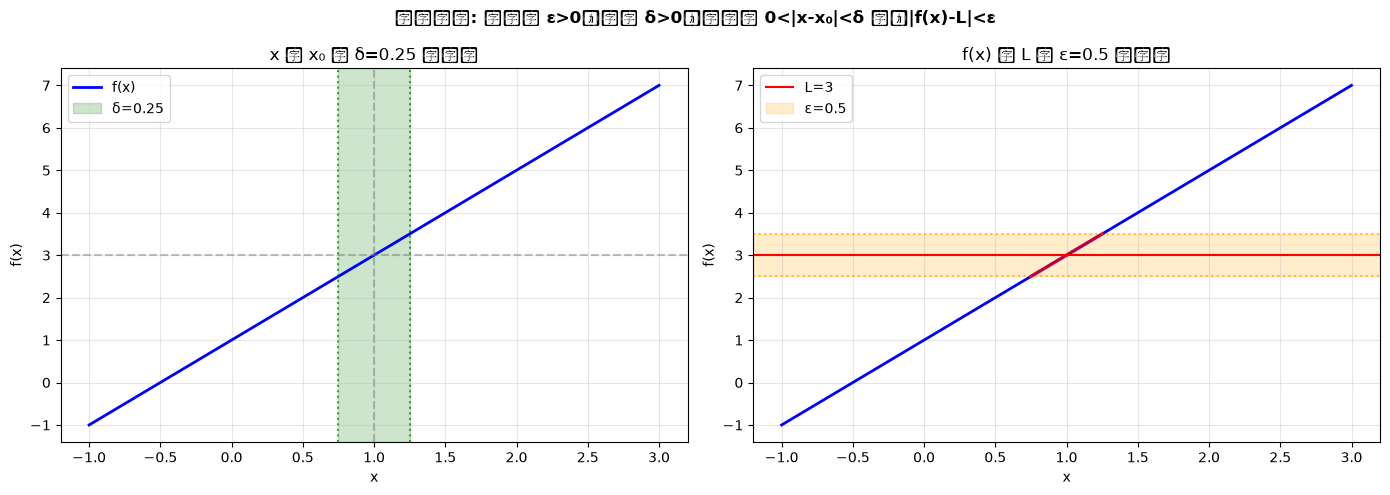

In [ ]:
# 在虚拟环境中先安装依赖
# pip install manim jupyter matplotlib numpy ipykernel -i https://pypi.tuna.tsinghua.edu.cn/simple

#%% [markdown]
# # Epsilon-Delta 极限定义可视化演示

#%%
import numpy as np
import matplotlib.pyplot as plt
from manim import *

#%%
# 首先在 Jupyter 中配置 manim
config.media_width = "75%"

#%% [markdown]
# ## 1. 使用 Matplotlib 演示 Epsilon-Delta

#%%
def plot_epsilon_delta(f, x0, L, epsilon=0.5, delta=0.3):
    """
    可视化 epsilon-delta 极限定义
    
    参数:
    f: 函数
    x0: 极限点
    L: 极限值
    epsilon: 给定的任意正数
    delta: 找到的正数
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 函数定义域
    x = np.linspace(x0 - 2, x0 + 2, 1000)
    y = f(x)
    
    # 左图：x-delta 区间
    ax1.plot(x, y, 'b-', linewidth=2, label=f'f(x)')
    ax1.axvline(x=x0, color='gray', linestyle='--', alpha=0.5)
    ax1.axhline(y=L, color='gray', linestyle='--', alpha=0.5)
    
    # 标记 delta 区域
    ax1.axvspan(x0 - delta, x0 + delta, alpha=0.2, color='green', label=f'δ={delta}')
    ax1.axvline(x=x0 - delta, color='green', linestyle=':', alpha=0.7)
    ax1.axvline(x=x0 + delta, color='green', linestyle=':', alpha=0.7)
    
    ax1.set_xlabel('x')
    ax1.set_ylabel('f(x)')
    ax1.set_title(f'x 在 x₀ 的 δ={delta} 邻域内')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 右图：y-epsilon 区间
    ax2.plot(x, y, 'b-', linewidth=2)
    ax2.axhline(y=L, color='red', linestyle='-', linewidth=1.5, label=f'L={L}')
    
    # 标记 epsilon 区域
    ax2.axhspan(L - epsilon, L + epsilon, alpha=0.2, color='orange', label=f'ε={epsilon}')
    ax2.axhline(y=L - epsilon, color='orange', linestyle=':', alpha=0.7)
    ax2.axhline(y=L + epsilon, color='orange', linestyle=':', alpha=0.7)
    
    # 高亮 delta 对应的 x 区间在函数上的映射
    x_delta = np.linspace(x0 - delta, x0 + delta, 500)
    ax2.plot(x_delta, f(x_delta), 'r-', linewidth=2.5, alpha=0.7)
    
    ax2.set_xlabel('x')
    ax2.set_ylabel('f(x)')
    ax2.set_title(f'f(x) 在 L 的 ε={epsilon} 邻域内')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 添加文本说明
    fig.suptitle(f'极限定义: 对任意 ε>0，存在 δ>0，使得当 0<|x-x₀|<δ 时，|f(x)-L|<ε', 
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

#%%
# 示例函数
def f1(x):
    return 2*x + 1

def f2(x):
    return x**2

def f3(x):
    return np.sin(x) / x  # 处理 x=0 的情况

#%%
# 演示 f(x) = 2x+1 在 x→1 时的极限
# 极限值 L = 3
x0, L = 1, 3
epsilon = 0.5
# 对于线性函数，delta = epsilon/2
delta = epsilon / 2

plot_epsilon_delta(f1, x0, L, epsilon, delta)

#%% [markdown]
# ### 演示：减小 epsilon，delta 如何变化

#%%
# 创建交互式滑块（如果支持）
from ipywidgets import interact, FloatSlider

def interactive_demo(epsilon=0.5):
    x0, L = 1, 3
    delta = epsilon / 2  # 对于 f(x)=2x+1
    plot_epsilon_delta(f1, x0, L, epsilon, delta)

interact(interactive_demo, epsilon=FloatSlider(min=0.1, max=1.0, step=0.1, value=0.5))

#%% [markdown]
# ## 2. 使用 Manim 创建动画演示

#%%
%%manim -qm EpsilonDeltaAnimation

class EpsilonDeltaAnimation(Scene):
    def construct(self):
        # 创建坐标轴
        axes = Axes(
            x_range=[-1, 5, 1],
            y_range=[-1, 7, 1],
            x_length=8,
            y_length=6,
            axis_config={"include_tip": True}
        )
        
        # 函数 f(x) = 2x + 1
        graph = axes.plot(lambda x: 2*x + 1, color=BLUE)
        
        # 点 x0=1, L=3
        x0 = 1
        L = 3
        dot_x0 = Dot(axes.coords_to_point(x0, 0), color=YELLOW)
        dot_L = Dot(axes.coords_to_point(x0, L), color=RED)
        
        # 标签
        x0_label = MathTex("x_0=1").next_to(dot_x0, DOWN)
        L_label = MathTex("L=3").next_to(dot_L, RIGHT)
        
        # epsilon 和 delta
        epsilon = 0.8
        delta = 0.4
        
        # Epsilon 带
        epsilon_band = axes.get_horizontal_line(
            axes.coords_to_point(0, L + epsilon),
            color=ORANGE, 
            stroke_width=4
        ).set_opacity(0.3)
        
        epsilon_band_low = axes.get_horizontal_line(
            axes.coords_to_point(0, L - epsilon),
            color=ORANGE, 
            stroke_width=4
        ).set_opacity(0.3)
        
        # Delta 带
        delta_band = axes.get_vertical_line(
            axes.coords_to_point(x0 - delta, 0),
            color=GREEN,
            stroke_width=4
        ).set_opacity(0.3)
        
        delta_band_right = axes.get_vertical_line(
            axes.coords_to_point(x0 + delta, 0),
            color=GREEN,
            stroke_width=4
        ).set_opacity(0.3)
        
        # 公式
        definition = MathTex(
            r"\forall \varepsilon > 0, \exists \delta > 0 \text{ 使得}",
            font_size=36
        ).to_edge(UP)
        
        condition = MathTex(
            r"0 < |x - x_0| < \delta \implies |f(x) - L| < \varepsilon",
            font_size=36
        ).next_to(definition, DOWN)
        
        # 动画序列
        self.play(Create(axes))
        self.play(Create(graph))
        self.wait(0.5)
        
        self.play(Create(dot_x0), Create(dot_L))
        self.play(Write(x0_label), Write(L_label))
        self.wait(0.5)
        
        self.play(Write(definition))
        self.play(Write(condition))
        self.wait(1)
        
        # 展示 epsilon
        self.play(
            Create(epsilon_band),
            Create(epsilon_band_low),
            Create(epsilon_band_low)
        )
        epsilon_text = MathTex(f"\\varepsilon = {epsilon}", color=ORANGE).to_edge(LEFT)
        self.play(Write(epsilon_text))
        self.wait(1)
        
        # 展示 delta
        self.play(
            Create(delta_band),
            Create(delta_band_right)
        )
        delta_text = MathTex(f"\\delta = {delta}", color=GREEN).next_to(epsilon_text, DOWN)
        self.play(Write(delta_text))
        self.wait(1)
        
        # 展示映射关系
        x_in_delta = np.linspace(x0 - delta, x0 + delta, 100)
        dots = VGroup(*[
            Dot(axes.coords_to_point(x, 2*x + 1), color=RED, radius=0.02)
            for x in x_in_delta[::5]
        ])
        
        self.play(Create(dots))
        self.wait(2)
        
        # 缩小 epsilon
        new_epsilon = 0.4
        new_delta = 0.2
        
        self.play(
            epsilon_band.animate.become(
                axes.get_horizontal_line(
                    axes.coords_to_point(0, L + new_epsilon),
                    color=ORANGE,
                    stroke_width=4
                ).set_opacity(0.3)
            ),
            epsilon_band_low.animate.become(
                axes.get_horizontal_line(
                    axes.coords_to_point(0, L - new_epsilon),
                    color=ORANGE,
                    stroke_width=4
                ).set_opacity(0.3)
            ),
            delta_band.animate.become(
                axes.get_vertical_line(
                    axes.coords_to_point(x0 - new_delta, 0),
                    color=GREEN,
                    stroke_width=4
                ).set_opacity(0.3)
            ),
            delta_band_right.animate.become(
                axes.get_vertical_line(
                    axes.coords_to_point(x0 + new_delta, 0),
                    color=GREEN,
                    stroke_width=4
                ).set_opacity(0.3)
            ),
            Transform(epsilon_text, MathTex(f"\\varepsilon = {new_epsilon}", color=ORANGE).to_edge(LEFT)),
            Transform(delta_text, MathTex(f"\\delta = {new_delta}", color=GREEN).next_to(epsilon_text, DOWN))
        )
        
        self.wait(2)
        
        # 最终结论
        conclusion = MathTex(
            r"\text{当 } \varepsilon \to 0 \text{ 时，} \delta \to 0",
            color=YELLOW,
            font_size=40
        ).to_edge(DOWN)
        
        self.play(Write(conclusion))
        self.wait(2)

#%% [markdown]
# ## 3. 数学解释

#%%
from IPython.display import display, Math, Latex

display(Math(r"\textbf{Epsilon-Delta 极限定义：}"))
display(Math(r"\lim_{x \to x_0} f(x) = L"))
display(Math(r"\forall \varepsilon > 0, \exists \delta > 0, \text{ 使得 } 0 < |x - x_0| < \delta \implies |f(x) - L| < \varepsilon"))

#%% [markdown]
# ### 关键点：
# 1. **任意给定** ε > 0（无论多小）
# 2. **存在** δ > 0（依赖于 ε）
# 3. 当 x 在 x₀ 的 δ 邻域内（但不等于 x₀）
# 4. f(x) 必定落在 L 的 ε 邻域内

#%%
# 不同函数的 delta 计算
def find_delta_linear(epsilon, slope=2):
    """对于 f(x)=mx+b, delta = epsilon/|m|"""
    return epsilon / abs(slope)

def find_delta_quadratic(epsilon, x0=1):
    """对于 f(x)=x² 在 x0=1 附近，delta = min(1, epsilon/3)"""
    return min(1, epsilon / 3)

# 测试
epsilons = [1.0, 0.5, 0.1, 0.01]
print("对于 f(x)=2x+1 在 x→1:")
for eps in epsilons:
    delta = find_delta_linear(eps)
    print(f"  ε={eps:.2f} → δ={delta:.4f}")

#%% [markdown]
# ## 4. 使用说明
# 
# 1. 运行 Matplotlib 部分可以直接看到静态图
# 2. 运行 Manim 部分需要：
#    - 安装 manim: `pip install manim`
#    - 在 Jupyter 中渲染动画
# 3. 可以修改函数和参数来探索不同的极限

#%% 
# 更多示例
print("\n测试不同的 epsilon 值:")
for eps in [0.5, 0.2, 0.1, 0.05]:
    print(f"\nε = {eps}")
    print(f"δ = {find_delta_linear(eps)}")
    print(f"验证: 当 |x-1|<{find_delta_linear(eps)} 时")
    print(f"|f(x)-3| = |(2x+1)-3| = 2|x-1| < 2·{find_delta_linear(eps)} = {eps} ✓")